# RideWise · Notebook 05 — Churn Modelling

**Train and fairly evaluate Logistic Regression and Random Forest churn classifiers, with imbalance-aware metrics.**

---

### What you will learn
- Why we use two model families, not one
- How to split data so evaluation is honest
- Why accuracy lies under class imbalance, and what to use instead
- How to read ROC-AUC, PR-AUC, precision and recall together

### How to read this notebook
Every section follows the same rhythm used throughout the project:
**the business question first**, then the data, then the method, then a
**validation check** that proves the step did what we claimed. Run the cells
top to bottom; nothing depends on hidden state.

---

## 1. The business question

Given everything we know about a rider at the snapshot, **how likely are they
to churn in the next 30 days?** We want a probability per rider, and we want to
trust it. Two models give us a cross-check: a transparent linear one and a
flexible non-linear one.

In [1]:
# --- environment setup (run me first) ---
import sys, os
from pathlib import Path

# Make the shared pipeline importable whether you launch from notebooks/ or root
ROOT = Path.cwd()
if (ROOT / "src").exists():
    SRC = ROOT / "src"
elif (ROOT.parent / "src").exists():
    SRC = ROOT.parent / "src"
else:
    raise FileNotFoundError("Could not locate the src/ folder with ridewise_pipeline.py")
sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print("Setup OK · pipeline module at:", SRC)

Setup OK · pipeline module at: /home/claude/ridewise/src


In [2]:
from ridewise_pipeline import build_analytics_table, FEATURE_COLUMNS, RANDOM_STATE
df = build_analytics_table()
X = df[FEATURE_COLUMNS].fillna(0)
y = df["churn"]
print("Features:", X.shape, "| churn rate:", f"{y.mean():.1%}")

Features: (10000, 22) | churn rate: 28.9%


## 2. An honest split

We hold out 25% of riders the models never see during training, and **stratify**
so the churn rate is identical in both halves. We never look at the test set
until the very end.

In [3]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {len(X_tr):,} (churn {y_tr.mean():.1%})   Test: {len(X_te):,} (churn {y_te.mean():.1%})")

Train: 7,500 (churn 28.9%)   Test: 2,500 (churn 28.9%)


## 3. Model A — Logistic Regression (the transparent baseline)

A linear model whose coefficients give a signed, readable story about each
driver. We scale features first (logistic regression is sensitive to scale) and
use `class_weight='balanced'` so the minority churn class is not ignored.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)
lr = LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5).fit(X_tr_s, y_tr)
print("Logistic Regression trained.")

Logistic Regression trained.


## 4. Model B — Random Forest (the flexible workhorse)

An ensemble of decision trees that captures non-linear effects and feature
interactions automatically. No scaling needed. We cap depth and set a minimum
leaf size to keep it from memorising the training set.

In [5]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=400, max_depth=10, min_samples_leaf=20,
                            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1).fit(X_tr, y_tr)
print("Random Forest trained.")

Random Forest trained.


## 5. Why accuracy lies — and the metrics we use instead

About a quarter of riders churn. A lazy model predicting "nobody churns" scores
~75% accuracy while being useless. So we judge models on:

- **ROC-AUC** — ranking quality across all thresholds (0.5 = random, 1.0 = perfect).
- **PR-AUC** — precision/recall trade-off, the right lens under imbalance; compare it to the churn base rate.
- **Recall** — of the riders who really churn, how many did we catch?
- **Precision** — of the riders we flagged, how many really churn?

In [6]:
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, brier_score_loss)

def evaluate(name, model, X_eval):
    p = model.predict_proba(X_eval)[:, 1]
    pred = (p >= 0.5).astype(int)
    return {
        "model": name,
        "ROC_AUC": round(roc_auc_score(y_te, p), 3),
        "PR_AUC": round(average_precision_score(y_te, p), 3),
        "precision": round(precision_score(y_te, pred), 3),
        "recall": round(recall_score(y_te, pred), 3),
        "F1": round(f1_score(y_te, pred), 3),
        "Brier": round(brier_score_loss(y_te, p), 3),
    }

import pandas as pd
results = pd.DataFrame([evaluate("LogisticRegression", lr, X_te_s),
                        evaluate("RandomForest", rf, X_te)])
print("Churn base rate (PR-AUC baseline):", f"{y_te.mean():.3f}")
results

Churn base rate (PR-AUC baseline): 0.289


,model,ROC_AUC,PR_AUC,precision,recall,F1,Brier
0,LogisticRegression,0.787,0.630,0.519,0.688,0.592,0.184
1,RandomForest,0.784,0.626,0.534,0.672,0.595,0.179


**Reading it:** both models land around **ROC-AUC 0.78–0.80** and **PR-AUC ~0.63**
versus a ~0.25 base rate — that is a large lift, and the agreement between two
different model families tells us the signal is real, not a quirk of one method.

## 6. Visual evaluation

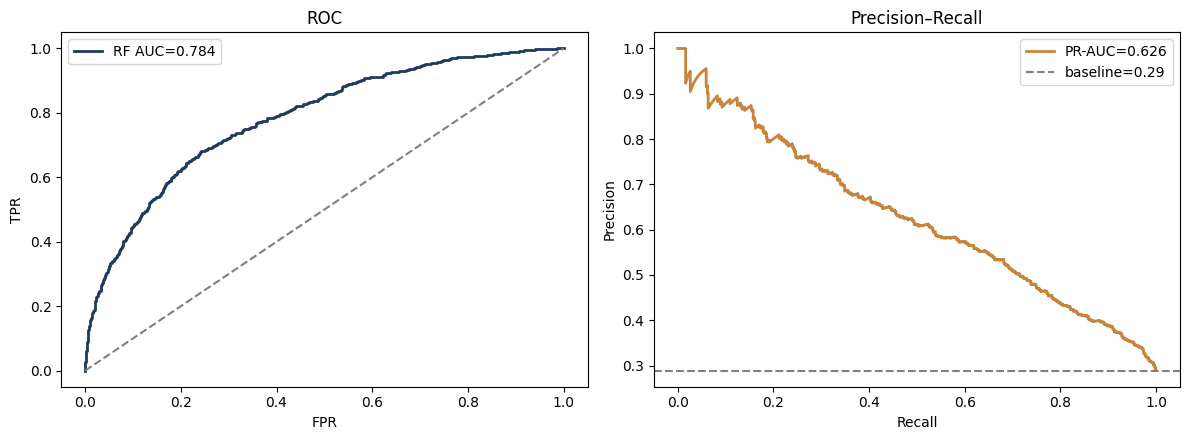

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve
NAVY, ACCENT = "#1F3A5F", "#C8843C"
p_rf = rf.predict_proba(X_te)[:, 1]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
fpr, tpr, _ = roc_curve(y_te, p_rf)
ax[0].plot(fpr, tpr, color=NAVY, lw=2, label=f"RF AUC={roc_auc_score(y_te, p_rf):.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="grey"); ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
pr, rc, _ = precision_recall_curve(y_te, p_rf)
ax[1].plot(rc, pr, color=ACCENT, lw=2, label=f"PR-AUC={average_precision_score(y_te, p_rf):.3f}")
ax[1].axhline(y_te.mean(), ls="--", color="grey", label=f"baseline={y_te.mean():.2f}")
ax[1].set_title("Precision–Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Cross-validation stability check

In [8]:
from sklearn.model_selection import cross_val_score
cv = cross_val_score(rf, X, y, cv=5, scoring="roc_auc", n_jobs=-1)
print(f"5-fold ROC-AUC: {cv.mean():.3f} +/- {cv.std():.3f}")
print("Low variance across folds = a stable model, not a lucky split.")

5-fold ROC-AUC: 0.784 +/- 0.017
Low variance across folds = a stable model, not a lucky split.


## 8. Save the models for deployment

In [9]:
import joblib
from pathlib import Path
mdir = (Path.cwd() / "models") if (Path.cwd() / "models").exists() else (Path.cwd().parent / "models")
mdir.mkdir(exist_ok=True)
joblib.dump({"model": rf, "features": FEATURE_COLUMNS}, mdir / "churn_rf.joblib")
joblib.dump({"model": lr, "scaler": scaler, "features": FEATURE_COLUMNS}, mdir / "churn_lr.joblib")
print("Saved models to", mdir)

Saved models to /home/claude/ridewise/models


## 9. Summary

- Two complementary models, both imbalance-aware, both ~0.78–0.80 ROC-AUC.
- Evaluation is honest: stratified hold-out, never peeked, judged on PR-AUC and recall.
- Cross-validation confirms stability; models serialised for serving.

**Next:** Notebook 06 explains *why* the model says what it says.